# Deteksi Mutasi Titik (Point Mutation) pada Gen TP53 Kanker
# Menggunakan Smith-Waterman Algorithm

---

## 1. Pendahuluan

**TP53** adalah gen penekan tumor (tumor suppressor gene) yang paling sering bermutasi pada kanker manusia. Protein p53 yang dikode oleh gen ini berperan penting dalam:
- Regulasi siklus sel
- Perbaikan DNA
- Apoptosis (kematian sel terprogram)

**Mutasi titik (point mutation)** adalah perubahan pada satu pasang basa nukleotida, yang meliputi:
1. **Substitusi** — pergantian satu basa dengan basa lain
2. **Insersi** — penyisipan satu basa tambahan
3. **Delesi** — penghapusan satu basa

Pada notebook ini, kita menggunakan **Smith-Waterman Algorithm** (local alignment) untuk membandingkan sekuens TP53 mutan dengan referensi wildtype dan mendeteksi mutasi titik.

## 2. Setup dan Import Library

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from Bio import SeqIO

# Tambahkan path root project agar bisa import modul src
sys.path.insert(0, os.path.abspath('..'))

from src.smith_waterman import smith_waterman, AlignmentResult
from src.mutation_detector import detect_mutations, summarize_mutations, Mutation, MutationType

print("✅ Semua library berhasil diimpor!")

✅ Semua library berhasil diimpor!


## 3. Load Data Sekuens FASTA

Kita memuat:
- **Sekuens referensi** TP53 wildtype (normal)
- **Sekuens mutan** — sampel yang akan dianalisis

In [2]:
# Load sekuens referensi
ref_record = next(SeqIO.parse("../data/tp53_reference.fasta", "fasta"))
ref_seq = str(ref_record.seq)

print(f"📋 Referensi: {ref_record.id}")
print(f"   Panjang : {len(ref_seq)} bp")
print(f"   Preview : {ref_seq[:80]}...")
print()

# Load sekuens mutan
mutant_records = list(SeqIO.parse("../data/tp53_mutant.fasta", "fasta"))

print(f"🧬 Jumlah sampel mutan: {len(mutant_records)}")
for rec in mutant_records:
    print(f"   - {rec.id} ({len(rec.seq)} bp)")

📋 Referensi: TP53_Wildtype_Reference
   Panjang : 570 bp
   Preview : ATGACTGCCATGGAGGAGTCACAGTCGGATATCAGCCTCGAGCTCCCTCTGAGTCAGGAAACATTTTCAGACCTATGGAA...

🧬 Jumlah sampel mutan: 4
   - TP53_Mutant_Sample_R175H (570 bp)
   - TP53_Mutant_Sample_R248W (570 bp)
   - TP53_Mutant_Sample_Deletion (569 bp)
   - TP53_Mutant_Sample_Insertion (571 bp)


## 1. Data Understanding Visualizations
Mari kita eksplorasi data sekuens DNA sebelum melakukan alignment. Kita akan melihat distribusi panjang sekuens, *GC-content*, dan komposisi basa (A, C, G, T).

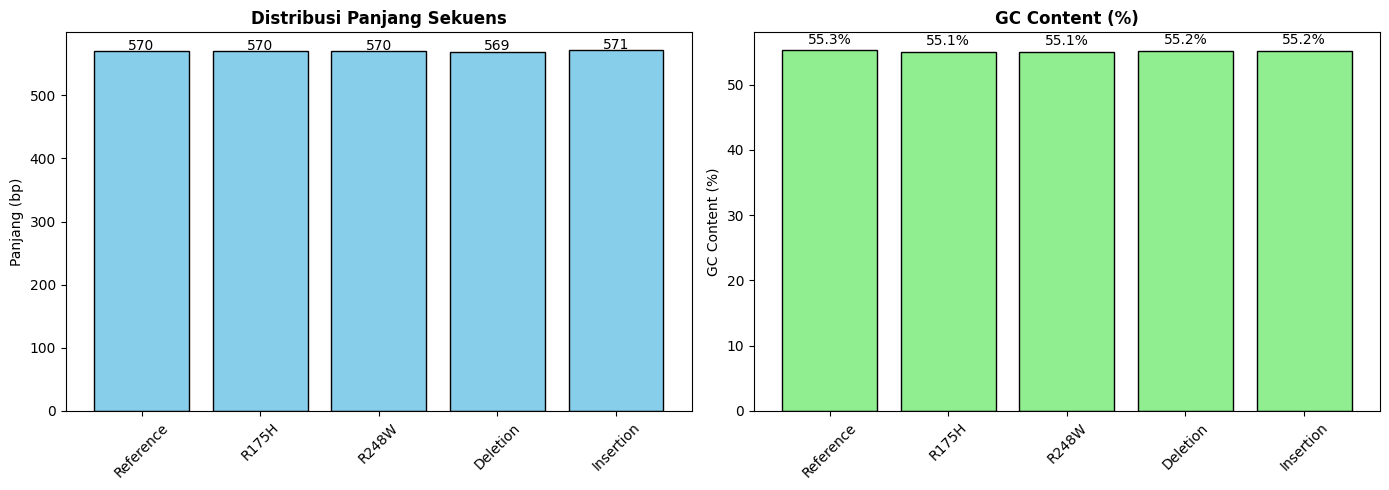

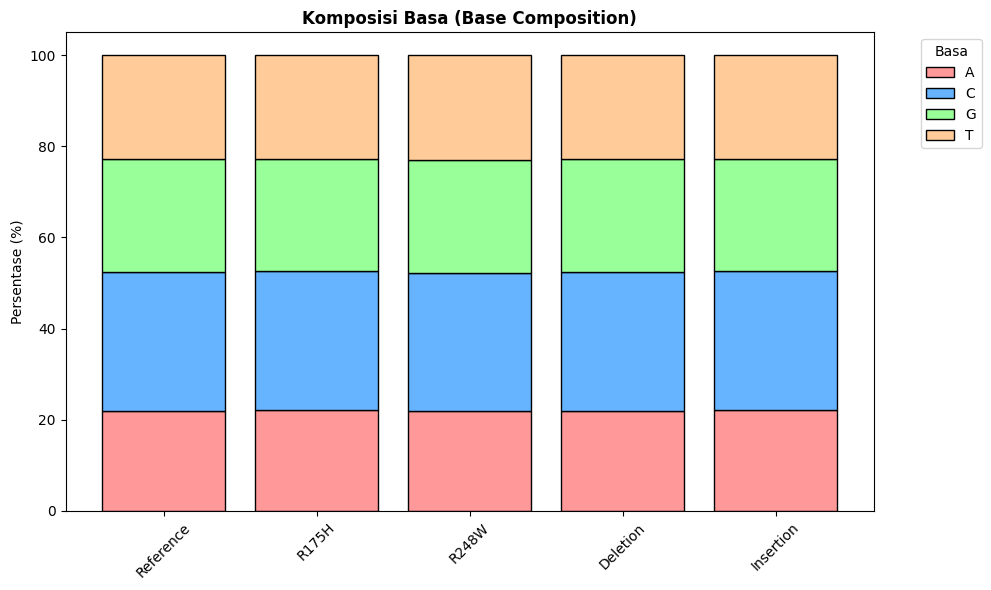

In [3]:
import collections

# 1. Data Understanding Visualizations
all_records = [ref_record] + mutant_records
labels = ['Reference'] + [rec.id.replace('TP53_Mutant_Sample_', '') for rec in mutant_records]
seqs = [str(rec.seq) for rec in all_records]

# Sequence lengths
lengths = [len(s) for s in seqs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Lengths
ax1.bar(labels, lengths, color='skyblue', edgecolor='black')
ax1.set_title('Distribusi Panjang Sekuens', fontweight='bold')
ax1.set_ylabel('Panjang (bp)')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(lengths):
    ax1.text(i, v + 2, str(v), ha='center')

# Plot GC Content
gc_contents = [(s.count('G') + s.count('C')) / len(s) * 100 for s in seqs]
ax2.bar(labels, gc_contents, color='lightgreen', edgecolor='black')
ax2.set_title('GC Content (%)', fontweight='bold')
ax2.set_ylabel('GC Content (%)')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(gc_contents):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# Base Composition
bases = ['A', 'C', 'G', 'T']
comp_data = {b: [] for b in bases}
for s in seqs:
    for b in bases:
        comp_data[b].append(s.count(b) / len(s) * 100)

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(labels))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

for i, b in enumerate(bases):
    ax.bar(labels, comp_data[b], bottom=bottom, label=b, color=colors[i], edgecolor='black')
    bottom += np.array(comp_data[b])

ax.set_title('Komposisi Basa (Base Composition)', fontweight='bold')
ax.set_ylabel('Persentase (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Basa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Data Preprocessing
Tahap preprocessing bertujuan untuk membersihkan data sekuens dari karakter-karakter yang tidak valid (selain A, C, G, T) seperti ambigous bases (N) dan mengubah semuanya menjadi huruf kapital (uppercase) agar hasil alignment akurat.

PROSES PREPROCESSING DATA
Referensi: 0 karakter tidak valid dihapus. Panjang akhir: 570


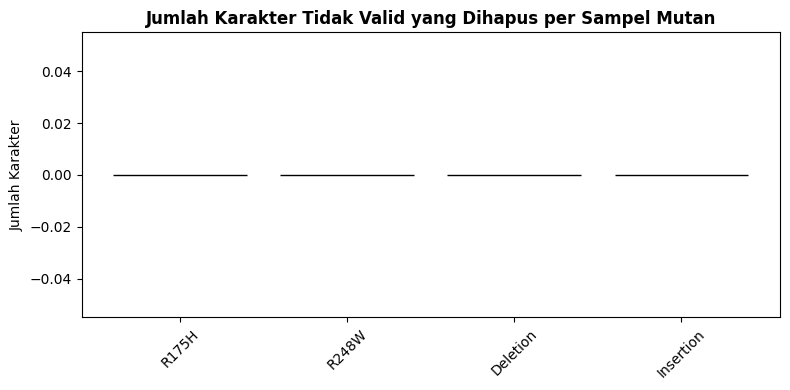

✅ Semua sekuens mutan sudah bersih, tidak ada karakter invalid (N, dll) yang ditemukan!


In [4]:
# 2. Data Preprocessing Visualizations
print("=" * 60)
print("PROSES PREPROCESSING DATA")
print("=" * 60)

def preprocess_sequence(seq):
    seq_upper = seq.upper()
    valid_bases = set('ACGT')
    invalid_chars = [c for c in seq_upper if c not in valid_bases]
    
    cleaned_seq = ''.join([c for c in seq_upper if c in valid_bases])
    return cleaned_seq, invalid_chars

# Proses referensi
ref_seq_clean, ref_invalid = preprocess_sequence(ref_seq)
print(f"Referensi: {len(ref_invalid)} karakter tidak valid dihapus. Panjang akhir: {len(ref_seq_clean)}")
ref_seq = ref_seq_clean # Update

cleaned_records = []
invalid_counts = []
for rec in mutant_records:
    clean_seq, inv = preprocess_sequence(str(rec.seq))
    invalid_counts.append(len(inv))
    # Update record
    rec.seq = rec.seq.__class__(clean_seq)
    cleaned_records.append(rec)

mutant_records = cleaned_records # Update dengan yang sudah dibersihkan

# Visualisasi Hasil Preprocessing
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels[1:], invalid_counts, color='salmon', edgecolor='black')
ax.set_title('Jumlah Karakter Tidak Valid yang Dihapus per Sampel Mutan', fontweight='bold')
ax.set_ylabel('Jumlah Karakter')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

if sum(invalid_counts) == 0:
    print("✅ Semua sekuens mutan sudah bersih, tidak ada karakter invalid (N, dll) yang ditemukan!")

## 4. Implementasi Smith-Waterman Algorithm

### 4.1 Penjelasan Algoritma

Smith-Waterman adalah algoritma **local sequence alignment** yang menggunakan **dynamic programming** untuk menemukan alignment lokal optimal antara dua sekuens.

#### Langkah-langkah:
1. **Inisialisasi**: Buat matriks scoring H berukuran (m+1) × (n+1), isi baris/kolom pertama dengan 0
2. **Pengisian Matriks**: Untuk setiap sel H(i,j), hitung:
   
   $H(i,j) = \max\begin{cases} 0 \\ H(i-1,j-1) + s(a_i, b_j) & \text{(match/mismatch)} \\ H(i-1,j) + d & \text{(gap di sekuens 2)} \\ H(i,j-1) + d & \text{(gap di sekuens 1)} \end{cases}$

3. **Traceback**: Mulai dari skor tertinggi, ikuti arah traceback hingga mencapai sel bernilai 0

#### Parameter Scoring:
- Match: +2
- Mismatch: -1
- Gap penalty: -1

### 4.2 Demonstrasi dengan Sekuens Pendek

Sebelum analisis penuh, mari kita demonstrasikan algoritma dengan sekuens pendek untuk memahami cara kerjanya.

In [5]:
# Demonstrasi dengan sekuens pendek
demo_ref   = "ACGTACGT"
demo_query = "ACGAACGT"  # Substitusi T→A di posisi 4

demo_result = smith_waterman(demo_ref, demo_query)

print("=" * 50)
print("DEMO: Smith-Waterman Local Alignment")
print("=" * 50)
print(f"Referensi : {demo_ref}")
print(f"Query     : {demo_query}")
print(f"\nSkor alignment  : {demo_result.score}")
print(f"Identity        : {demo_result.identity:.1f}%")
print(f"\nHasil Alignment:")
print(f"  Ref  : {demo_result.aligned_seq1}")
print(f"         {''.join('|' if a == b else 'X' for a, b in zip(demo_result.aligned_seq1, demo_result.aligned_seq2))}")
print(f"  Query: {demo_result.aligned_seq2}")

DEMO: Smith-Waterman Local Alignment
Referensi : ACGTACGT
Query     : ACGAACGT

Skor alignment  : 13
Identity        : 87.5%

Hasil Alignment:
  Ref  : ACGTACGT
         |||X||||
  Query: ACGAACGT


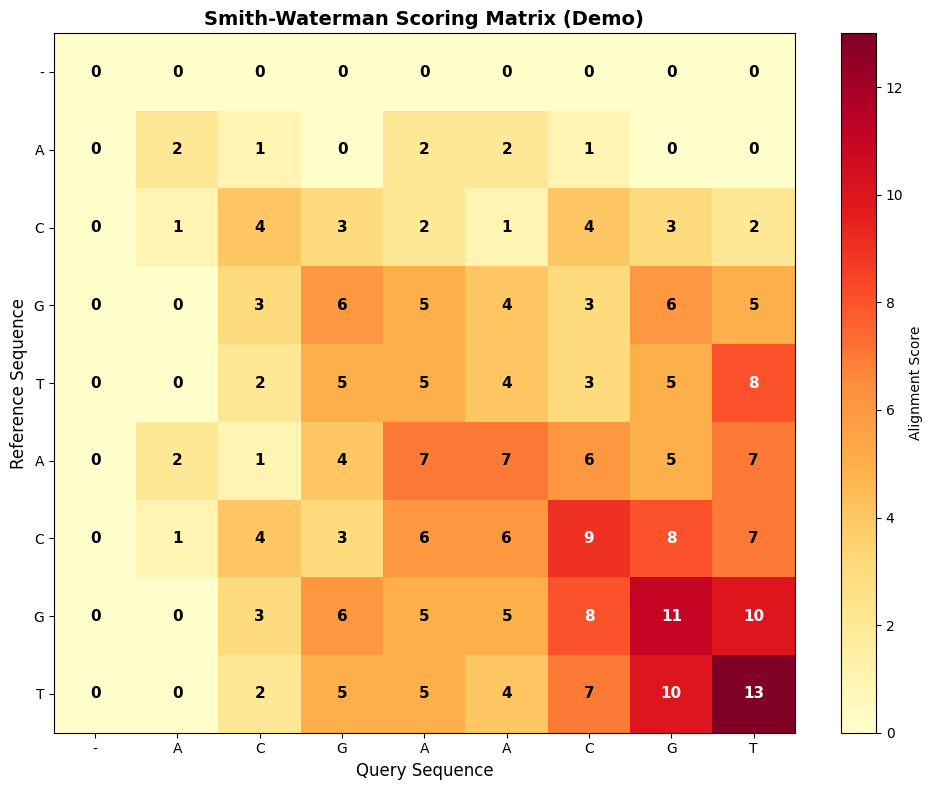

In [6]:
# Visualisasi matriks scoring untuk demo
fig, ax = plt.subplots(figsize=(10, 8))

H = demo_result.score_matrix
im = ax.imshow(H, cmap='YlOrRd', aspect='auto')

# Label sumbu
ax.set_xticks(range(len(demo_query) + 1))
ax.set_yticks(range(len(demo_ref) + 1))
ax.set_xticklabels(['-'] + list(demo_query))
ax.set_yticklabels(['-'] + list(demo_ref))
ax.set_xlabel('Query Sequence', fontsize=12)
ax.set_ylabel('Reference Sequence', fontsize=12)
ax.set_title('Smith-Waterman Scoring Matrix (Demo)', fontsize=14, fontweight='bold')

# Tampilkan nilai di setiap sel
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        ax.text(j, i, str(H[i, j]), ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if H[i, j] > H.max() * 0.6 else 'black')

plt.colorbar(im, label='Alignment Score')
plt.tight_layout()
plt.show()

## 5. Analisis Mutasi pada Sekuens TP53

Sekarang kita jalankan Smith-Waterman pada setiap sampel mutan dan deteksi mutasi titik yang ada.

In [7]:
# Jalankan alignment dan deteksi mutasi untuk setiap sampel
results = {}

for record in mutant_records:
    mut_seq = str(record.seq)
    
    # Smith-Waterman alignment
    alignment = smith_waterman(ref_seq, mut_seq)
    
    # Deteksi mutasi
    mutations = detect_mutations(alignment)
    summary = summarize_mutations(mutations)
    
    results[record.id] = {
        'alignment': alignment,
        'mutations': mutations,
        'summary': summary,
    }
    
    print("=" * 60)
    print(f"🧬 Sampel: {record.id}")
    print(f"   Deskripsi: {record.description}")
    print(f"   Skor Alignment : {alignment.score}")
    print(f"   Identity       : {alignment.identity:.1f}%")
    print(f"   Total Mutasi   : {summary['total']}")
    print(f"     - Substitusi : {summary['substitusi']}")
    print(f"     - Insersi    : {summary['insersi']}")
    print(f"     - Delesi     : {summary['delesi']}")
    print()
    
    if mutations:
        print("   Mutasi yang terdeteksi:")
        for mut in mutations:
            print(f"     {mut}")
    print()

🧬 Sampel: TP53_Mutant_Sample_R175H
   Deskripsi: TP53_Mutant_Sample_R175H Hotspot mutation R175H (CGC>CAC) - missense substitution
   Skor Alignment : 1137
   Identity       : 99.8%
   Total Mutasi   : 1
     - Substitusi : 1
     - Insersi    : 0
     - Delesi     : 0

   Mutasi yang terdeteksi:
     [Substitusi] Posisi 531: G → A | Konteks: ...GAACCGGAGGC...

🧬 Sampel: TP53_Mutant_Sample_R248W
   Deskripsi: TP53_Mutant_Sample_R248W Hotspot mutation R248W (CGG>TGG) - missense substitution
   Skor Alignment : 1137
   Identity       : 99.8%
   Total Mutasi   : 1
     - Substitusi : 1
     - Insersi    : 0
     - Delesi     : 0

   Mutasi yang terdeteksi:
     [Substitusi] Posisi 530: C → T | Konteks: ...TGAACCGGAGG...

🧬 Sampel: TP53_Mutant_Sample_Deletion
   Deskripsi: TP53_Mutant_Sample_Deletion Single base deletion at position 150
   Skor Alignment : 1137
   Identity       : 99.8%
   Total Mutasi   : 1
     - Substitusi : 0
     - Insersi    : 0
     - Delesi     : 1

   Mutasi yang 

## 6. Visualisasi Hasil

### 6.1 Perbandingan Skor Alignment

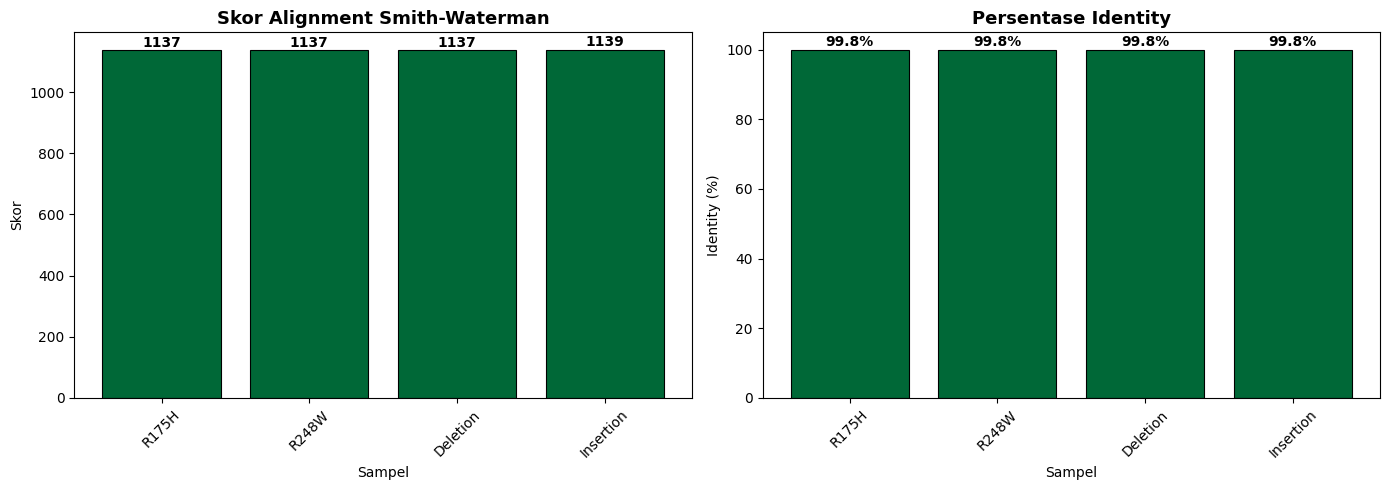

In [8]:
# Bar chart perbandingan skor alignment
sample_names = [name.replace('TP53_Mutant_Sample_', '') for name in results.keys()]
scores = [r['alignment'].score for r in results.values()]
identities = [r['alignment'].identity for r in results.values()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Skor alignment
colors = plt.cm.RdYlGn(np.array(identities) / 100)
bars1 = ax1.bar(sample_names, scores, color=colors, edgecolor='black', linewidth=0.8)
ax1.set_title('Skor Alignment Smith-Waterman', fontsize=13, fontweight='bold')
ax1.set_ylabel('Skor')
ax1.set_xlabel('Sampel')
ax1.tick_params(axis='x', rotation=45)
for bar, score in zip(bars1, scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(score), ha='center', va='bottom', fontweight='bold')

# Identity percentage
bars2 = ax2.bar(sample_names, identities, color=colors, edgecolor='black', linewidth=0.8)
ax2.set_title('Persentase Identity', fontsize=13, fontweight='bold')
ax2.set_ylabel('Identity (%)')
ax2.set_xlabel('Sampel')
ax2.set_ylim(0, 105)
ax2.tick_params(axis='x', rotation=45)
for bar, ident in zip(bars2, identities):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{ident:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.2 Distribusi Jenis Mutasi

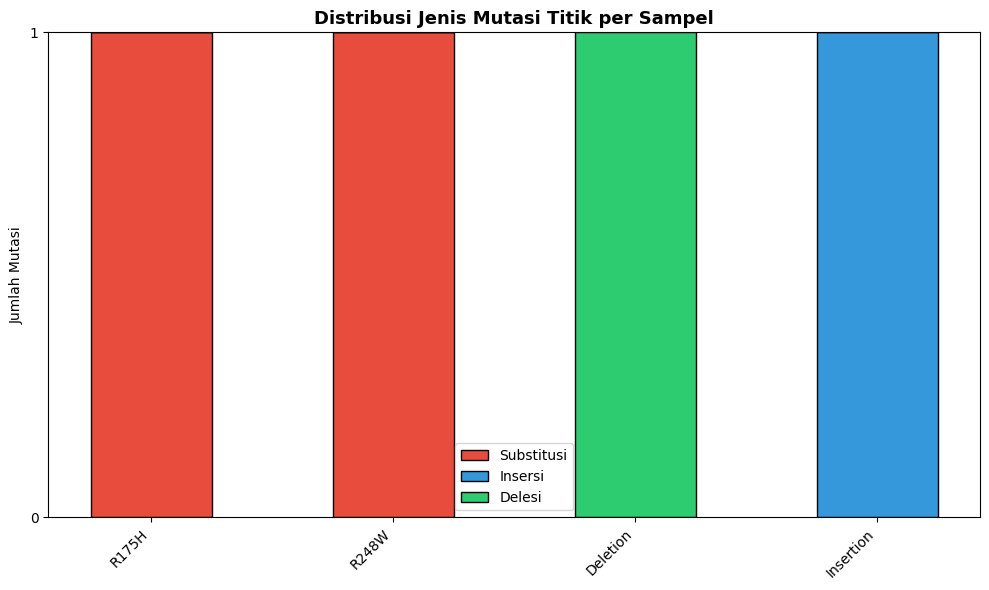

In [9]:
# Stacked bar chart jenis mutasi per sampel
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(sample_names))
width = 0.5

subs = [r['summary']['substitusi'] for r in results.values()]
ins = [r['summary']['insersi'] for r in results.values()]
dels = [r['summary']['delesi'] for r in results.values()]

ax.bar(x, subs, width, label='Substitusi', color='#e74c3c', edgecolor='black')
ax.bar(x, ins, width, bottom=subs, label='Insersi', color='#3498db', edgecolor='black')
ax.bar(x, dels, width, bottom=[s+i for s, i in zip(subs, ins)], label='Delesi', color='#2ecc71', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(sample_names, rotation=45, ha='right')
ax.set_ylabel('Jumlah Mutasi')
ax.set_title('Distribusi Jenis Mutasi Titik per Sampel', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### Peta Posisi Mutasi (Lollipop Plot)
Visualisasi ini menunjukkan distribusi posisi mutasi di sepanjang gen referensi TP53. Sangat berguna untuk mendeteksi area hotspot (area yang sering mengalami mutasi).

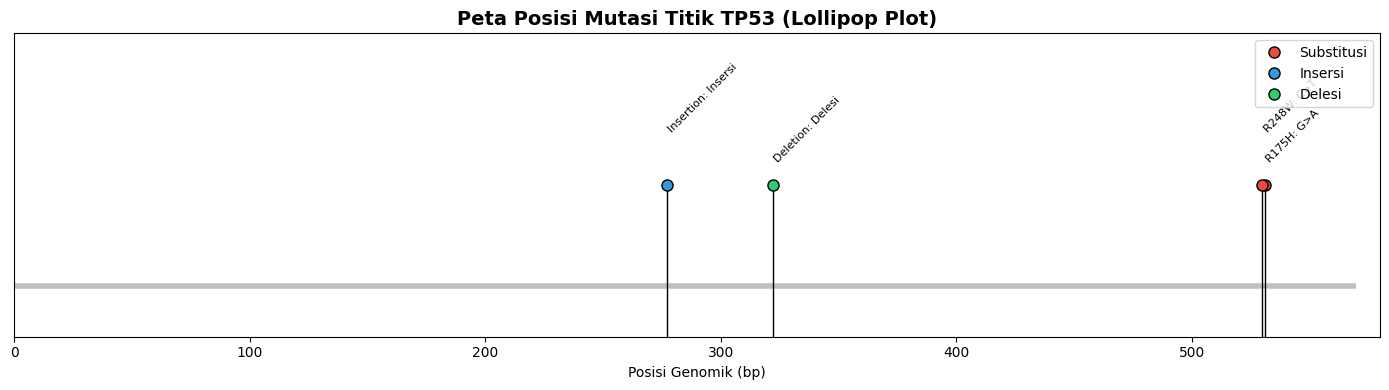

In [10]:
# Advanced Mutation Visualization (Lollipop Plot)
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(14, 4))

# Gambar gen reference sebagai garis
ax.hlines(1, 0, len(ref_seq), color='gray', linewidth=4, alpha=0.5, label='TP53 Reference Gene')

# Ekstrak semua mutasi
all_mutations_pos = []
all_mutations_type = []
all_mutations_desc = []

for sample, res in results.items():
    short_sample = sample.replace('TP53_Mutant_Sample_', '')
    for mut in res['mutations']:
        all_mutations_pos.append(mut.position)
        all_mutations_type.append(mut.mutation_type.value)
        desc = f"{short_sample}: {mut.ref_base}>{mut.mut_base}" if mut.mutation_type == MutationType.SUBSTITUTION else f"{short_sample}: {mut.mutation_type.value}"
        all_mutations_desc.append(desc)

# Pilihan warna berdasarkan jenis mutasi
color_map = {'Substitusi': '#e74c3c', 'Insersi': '#3498db', 'Delesi': '#2ecc71'}
colors = [color_map[m] for m in all_mutations_type]

# Plot batang (stem) mutasi
if all_mutations_pos: # Only plot if mutations exist
    markerline, stemlines, baseline = ax.stem(all_mutations_pos, [2]*len(all_mutations_pos), linefmt='k-', basefmt=" ")
    plt.setp(stemlines, 'linewidth', 1)
    # Hide the default markerline since we'll draw custom markers
    plt.setp(markerline, 'visible', False)

    # Ganti warna marker secara individual
    for i, pos in enumerate(all_mutations_pos):
        ax.plot(pos, 2, 'o', color=colors[i], markersize=8, markeredgecolor='black')
        # Teks label (opsional, karena bisa overlap jika banyak)
        ax.text(pos, 2.2 + (i%2)*0.3, all_mutations_desc[i], rotation=45, ha='left', va='bottom', fontsize=8)

# Dummy scatter untuk legend
legend_handles = [mlines.Line2D([], [], color=color_map[k], marker='o', linestyle='None',
                          markersize=8, markeredgecolor='black', label=k) for k in color_map.keys()]
ax.legend(handles=legend_handles, loc='upper right')

ax.set_title('Peta Posisi Mutasi Titik TP53 (Lollipop Plot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Posisi Genomik (bp)')
ax.set_yticks([]) # Sembunyikan sumbu y
ax.set_ylim(0.5, 3.5)
ax.set_xlim(0, len(ref_seq) + 10)

plt.tight_layout()
plt.show()

### 6.3 Heatmap Matriks Scoring (Sampel Pertama)

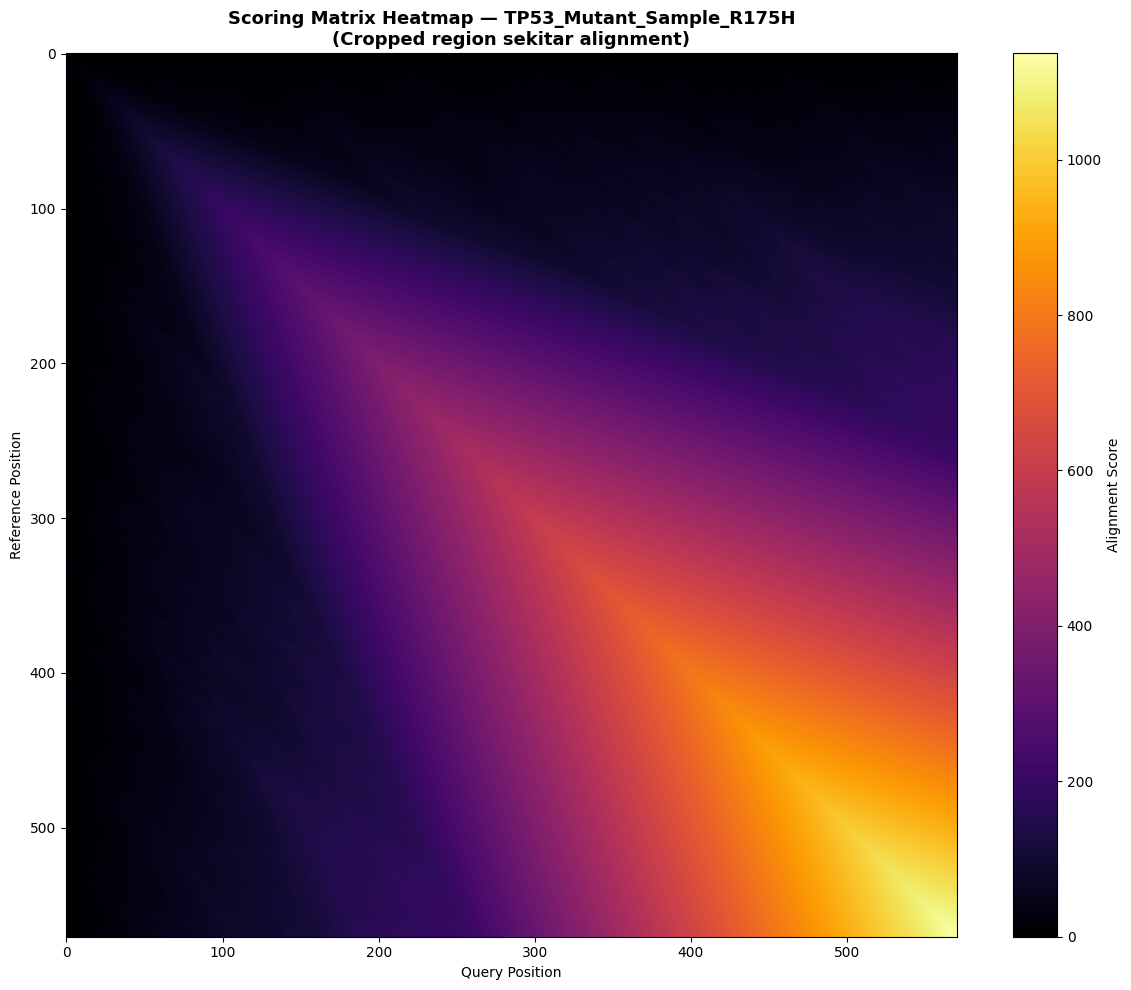

Ukuran matriks penuh: (571, 571)
Region ditampilkan: [0:571, 0:571]
Skor maksimum: 1137


In [11]:
# Heatmap matriks scoring untuk sampel pertama (cropped region)
first_sample = list(results.keys())[0]
H_full = results[first_sample]['alignment'].score_matrix

# Crop area sekitar alignment (terlalu besar untuk visualisasi penuh)
start_i = max(0, results[first_sample]['alignment'].start_pos[0] - 10)
end_i = min(H_full.shape[0], results[first_sample]['alignment'].end_pos[0] + 10)
start_j = max(0, results[first_sample]['alignment'].start_pos[1] - 10)
end_j = min(H_full.shape[1], results[first_sample]['alignment'].end_pos[1] + 10)

H_crop = H_full[start_i:end_i, start_j:end_j]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(H_crop, cmap='inferno', aspect='auto', interpolation='nearest')
ax.set_title(f'Scoring Matrix Heatmap — {first_sample}\n(Cropped region sekitar alignment)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Query Position')
ax.set_ylabel('Reference Position')
plt.colorbar(im, label='Alignment Score')
plt.tight_layout()
plt.show()

print(f"Ukuran matriks penuh: {H_full.shape}")
print(f"Region ditampilkan: [{start_i}:{end_i}, {start_j}:{end_j}]")
print(f"Skor maksimum: {H_full.max()}")

### 6.4 Visualisasi Alignment Detail

In [12]:
def visualize_alignment(alignment: AlignmentResult, sample_name: str, window: int = 80):
    """
    Menampilkan alignment dalam format yang mudah dibaca,
    mirip output BLAST.
    """
    ref_al = alignment.aligned_seq1
    query_al = alignment.aligned_seq2
    
    print(f"\n{'='*70}")
    print(f"Alignment Detail: {sample_name}")
    print(f"Score: {alignment.score} | Identity: {alignment.identity:.1f}%")
    print(f"{'='*70}")
    
    for start in range(0, len(ref_al), window):
        end = min(start + window, len(ref_al))
        ref_chunk = ref_al[start:end]
        query_chunk = query_al[start:end]
        
        # Baris pencocokan
        match_line = ''.join(
            '|' if r == q else ('.' if r == '-' or q == '-' else 'X')
            for r, q in zip(ref_chunk, query_chunk)
        )
        
        print(f"\nRef   {start+1:>5d}  {ref_chunk}  {end}")
        print(f"             {match_line}")
        print(f"Query {start+1:>5d}  {query_chunk}  {end}")

# Tampilkan alignment untuk setiap sampel
for sample_name, result in results.items():
    visualize_alignment(result['alignment'], sample_name)


Alignment Detail: TP53_Mutant_Sample_R175H
Score: 1137 | Identity: 99.8%

Ref       1  ATGACTGCCATGGAGGAGTCACAGTCGGATATCAGCCTCGAGCTCCCTCTGAGTCAGGAAACATTTTCAGACCTATGGAA  80
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Query     1  ATGACTGCCATGGAGGAGTCACAGTCGGATATCAGCCTCGAGCTCCCTCTGAGTCAGGAAACATTTTCAGACCTATGGAA  80

Ref      81  ACTACTTCCTGAAAACAACGTTCTGTCCCCCTTGCCGTCTGGGCTTCTTGCATTCTGGGACAGCCAAGTCTGTGACTTGC  160
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Query    81  ACTACTTCCTGAAAACAACGTTCTGTCCCCCTTGCCGTCTGGGCTTCTTGCATTCTGGGACAGCCAAGTCTGTGACTTGC  160

Ref     161  ACGTACTCCCCTGCCCTCAACAAGATGTTTTGCCAACTGGCCAAGACCTGCCCTGTGCAGCTGTGGGTTGATTCCACACC  240
             ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Query   161  ACGTACTCCCCTGCCCTCAACAAGATGTTTTGCCAACTGGCCAAGACCTGCCCTGTGCAGCTGTGGGTTGATTCCACACC  240

Ref     241  CCCGCCCGGCACCCGCGTCCGCGCCATGGCCATCT

## 7. Ringkasan dan Kesimpulan

In [13]:
print("\n" + "=" * 70)
print("RINGKASAN ANALISIS MUTASI TITIK GEN TP53")
print("=" * 70)
print(f"\n📊 Jumlah sampel dianalisis: {len(results)}")
print(f"📏 Panjang sekuens referensi: {len(ref_seq)} bp")
print(f"⚙️  Algoritma: Smith-Waterman (Local Alignment)")
print(f"   Parameter: Match=+2, Mismatch=-1, Gap=-1")

print("\n" + "-" * 70)
print(f"{'Sampel':<30} {'Skor':>8} {'Identity':>10} {'Mutasi':>8}")
print("-" * 70)

for name, result in results.items():
    short_name = name.replace('TP53_Mutant_Sample_', '')
    al = result['alignment']
    s = result['summary']
    print(f"{short_name:<30} {al.score:>8} {al.identity:>9.1f}% {s['total']:>8}")

print("-" * 70)

total_mutations = sum(r['summary']['total'] for r in results.values())
total_subs = sum(r['summary']['substitusi'] for r in results.values())
total_ins = sum(r['summary']['insersi'] for r in results.values())
total_dels = sum(r['summary']['delesi'] for r in results.values())

print(f"\n📈 Total mutasi terdeteksi: {total_mutations}")
print(f"   Substitusi : {total_subs}")
print(f"   Insersi    : {total_ins}")
print(f"   Delesi     : {total_dels}")
print("\n" + "=" * 70)


RINGKASAN ANALISIS MUTASI TITIK GEN TP53

📊 Jumlah sampel dianalisis: 4
📏 Panjang sekuens referensi: 570 bp
⚙️  Algoritma: Smith-Waterman (Local Alignment)
   Parameter: Match=+2, Mismatch=-1, Gap=-1

----------------------------------------------------------------------
Sampel                             Skor   Identity   Mutasi
----------------------------------------------------------------------
R175H                              1137      99.8%        1
R248W                              1137      99.8%        1
Deletion                           1137      99.8%        1
Insertion                          1139      99.8%        1
----------------------------------------------------------------------

📈 Total mutasi terdeteksi: 4
   Substitusi : 2
   Insersi    : 1
   Delesi     : 1

